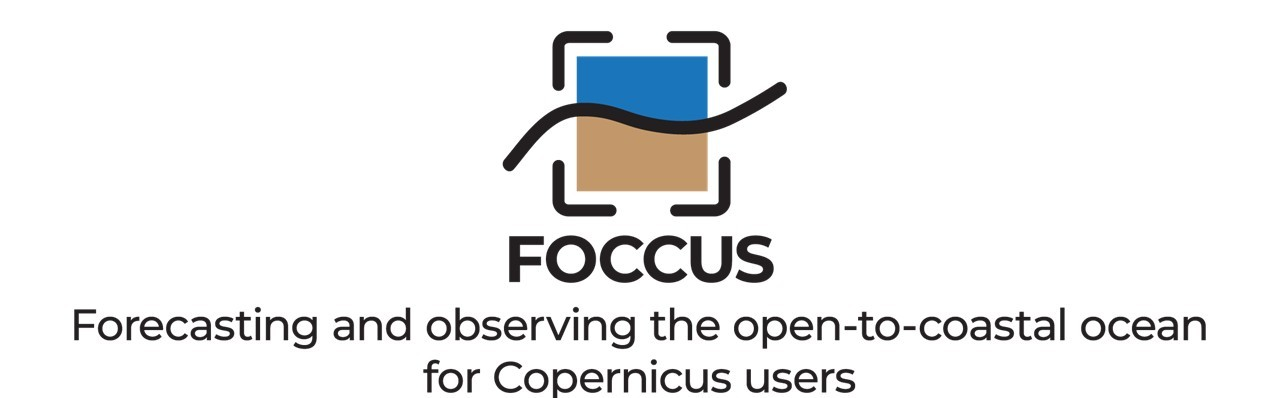
# FOCCUS Demonstrator: Land-Based Pollution in the North Sea

## **Objective and Background** 

The objective of this demonstrator is to showcase the results from Application 2.1.1.1 in [D8.1](https://zenodo.org/records/17064233 "D8.1")

**The goal of the application** is to assess the impact of **land-based (nutrient) pollution on eutrophication** in the North Sea, following the OSPAR Eutrophication Assessment common procedure. 
Therefore, this application assesses nutrient concentration (Total Nitrogen, Total Phosphorus) over the winter mean values, whilst the mean Chlorophyll-a concentrations are assessed over the growing period. For the period of 2015-2020, these concentratiosn are computed per OSPAR assessment areas. 

<details>
<summary> More details on the OSPAR Eutrophication Assessment</summary>

### What is the OSPAR Eutrophication Assessment?

OSPAR’s Eutrophication Assessment evaluates whether coastal and marine waters in the North-East Atlantic are affected by eutrophication—nutrient enrichment (mainly nitrogen and phosphorus) that can drive excessive algal growth and lead to impacts such as reduced water clarity, oxygen depletion, and ecosystem change. It provides a harmonised regional picture of eutrophication status to support consistent reporting and coordinated management action.

### What is assessed?

The assessment follows the cause–effect chain from **nutrient inputs/concentrations** (pressures) to **ecosystem responses** (effects), typically including indicators for nutrient enrichment, chlorophyll/phytoplankton biomass, nuisance algae/vegetation changes, and oxygen deficiency.

### How is the assessment carried out?

OSPAR uses an indicator-based “[common procedure](https://www.ospar.org/work-areas/hasec/eutrophication/common-procedure)”: define assessment areas, compile monitoring/model data, compare indicators to agreed criteria, and integrate results (weight of evidence) to assign overall eutrophication status, with documentation of confidence and data coverage.
</details>


        
Aditionally, to understand **how far** the land-based pollution plumes originating from rivers **reach into the North Sea**, we will also showcase results from our tracer runs. From this, the relative contribution of the pollutants originating from each countries can be shown. 

## **This notebook is structured as follows:**

1. Explore the different OSPAR assessment areas
2. Review the different Tracer Groups.
3. Explore the specific spatial reach of each tracer group (total nitrogen or total phosphorus)
4. An overview of the computed OSPAR Eutrophication Assessment metrics
5. An overview of the environmental quality marker per assessment area.
6. How was this application made, and where to find more information.


# 1. Explore the different OSPAR assessment areas

<p>
OSPAR assessment areas are spatial units used in the Common Procedure (COMP4) to assess eutrophication consistently across the North-East Atlantic. 
These areas are defined based on <b>ecological and physical characteristics</b>, such as salinity gradients, circulation patterns, depth, and proximity to nutrient sources, rather than national borders, so that each unit reflects a coherent marine system. 
    
They distinguish between environments such as <b>river plumes, coastal waters, shelf seas, and offshore regions</b>, each of which responds differently to nutrient enrichment. 
This harmonised spatial framework enables comparable assessment of indicators like nutrients, chlorophyll-a and oxygen across countries and supports consistent classification of ecological status. 

More detailed information can be found in the 
<a href="https://repository.oceanbestpractices.org/items/eef57bd2-59f0-4dd6-8557-b29d064244e6/full" target="_blank">OSPAR Common Procedure (2022 Agreement)</a>, 
the 
<a href="https://github.com/ices-tools-prod/COMPEAT" target="_blank">COMPEAT assessment tool</a>, 
and the 
<a href="https://oap.ospar.org/en/ospar-assessments/quality-status-reports/qsr-2023/thematic-assessments/eutrophication/state/" target="_blank">OSPAR QSR 2023 assessment portal</a>.
</p>

In [1]:
#imports

import warnings
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Polygon, MultiPolygon
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader as shapereader
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import interact
import xugrid as xu
import xarray as xr 
import matplotlib as mpl
import cmocean

In [2]:
extent_default = [-16, 15, 42, 64]

shp_path = r'data/COMP4_assessment_areas_v8a.shp'

# Load data
records = list(shapereader.Reader(shp_path).records())

df_all = pd.DataFrame({
    "ID": [r.attributes["ID"] for r in records],
    "Name": [r.attributes["LongName"] for r in records],
    "geometry": [r.geometry for r in records]
})


def in_extent(geom, extent):
    xmin, xmax, ymin, ymax = extent
    gxmin, gymin, gxmax, gymax = geom.bounds
    return not (gxmax < xmin or gxmin > xmax or gymax < ymin or gymin > ymax)


# Plot function 
def plot_current():

    extent = [xmin_slider.value,xmax_slider.value,ymin_slider.value,ymax_slider.value]

    with out:
        out.clear_output(wait=True)

        df = df_all[df_all.geometry.apply(lambda g: in_extent(g, extent))].reset_index(drop=True)

        n = len(df)
        colors = plt.cm.tab20(np.linspace(0, 1, min(20, n)))
        colors = np.tile(colors, (int(np.ceil(n/20)), 1))[:n]

        np.random.seed(42)
        np.random.shuffle(colors)
        df["color"] = list(colors)

        fig, ax = plt.subplots(figsize=(22, 16),subplot_kw={'projection': ccrs.PlateCarree()})

        ax.set_extent(extent)
        ax.coastlines(linewidth=1.2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.9)

        gl = ax.gridlines(draw_labels=True)
        gl.top_labels = gl.right_labels = False
        gl.xlines = gl.ylines = False

        # Polygons
        for geom, col in zip(df.geometry, df.color):
            ax.add_geometries(
                [geom],crs=ccrs.PlateCarree(),facecolor=col,edgecolor='black',linewidth=0.8,zorder=1)

        # Labels
        for geom, label in zip(df.geometry, df.ID):
            pt = geom.representative_point()
            ax.text(pt.x, pt.y,label,fontsize=9,ha='center',va='center',transform=ccrs.PlateCarree(),zorder=3)
            

        # Land overlay
        ax.add_feature(cfeature.LAND,facecolor='linen',edgecolor='k',zorder=2)

        # Legend
        handles = [
            mpatches.Patch(facecolor=c, edgecolor='black', label=f"{i} – {n}")
            for c, i, n in zip(df.color, df.ID, df.Name)
        ]

        fig.legend(handles=handles,loc='lower center',ncol=5,fontsize=9, frameon=False)

        plt.subplots_adjust(bottom=0.18)
        plt.show()


# Sliders
xmin_slider = widgets.FloatSlider(value=-16, min=-16, max=15, step=0.5, description='xmin')
xmax_slider = widgets.FloatSlider(value=15, min=-16, max=15, step=0.5, description='xmax')
ymin_slider = widgets.FloatSlider(value=42, min=42, max=64, step=0.5, description='ymin')
ymax_slider = widgets.FloatSlider(value=64, min=42, max=64, step=0.5, description='ymax')

# Buttons
plot_button = widgets.Button(description="Plot map", button_style='success')
reset_button = widgets.Button(description="Reset", button_style='')
out = widgets.Output()
def on_plot_clicked(b):
    plot_current()

def on_reset_clicked(b):
    xmin_slider.value, xmax_slider.value, ymin_slider.value, ymax_slider.value = extent_default

plot_button.on_click(on_plot_clicked)
reset_button.on_click(on_reset_clicked)

# Layout
ui = widgets.VBox([widgets.Label("Adjust extent:"),xmin_slider,xmax_slider,ymin_slider,ymax_slider,
    widgets.HBox([plot_button, reset_button]),out])

display(ui)


# 2. Review the different tracer sources. 

Tracer simulations in eutrophication models are used to track the origin and fate of nutrients (e.g. nitrogen and phosphorus) in the marine system. In practice, this means that each source of nutrients (e.g. a river, atmospheric deposition, or ocean inflow) is assigned its own “tracer”, which behaves exactly like the real nutrient but carries a label indicating its origin. As the model runs, these tracers are transported by currents, mixed, and taken up or transformed biologically. This allows the model to determine how much of the nutrient concentration in a given area comes from each source and to understand transport pathways, mixing processes, and transboundary effects.

To keep analysis manageable and easy to interpret, nutrient discharge locations are grouped into larger source categories basse on their geographic region/catchment to keep the analysis manageable and interpretable. 

The tracer study is conducted for two 'pollutants': 

1. [TN] = Total Nitrogen
2. [TP] =  Total Phosphorus 

Keep track of those group names that seem interesting to you, this way, you can explore those later!

In [3]:
# load data
file_path = r"data/River_perTarea_Feb.xlsx"
df = pd.read_excel(file_path, engine='openpyxl')
df = df.dropna(subset=["POURX", "POURY", "GROUP"])

#menu
groups = sorted(df["GROUP"].unique())

dropdown = widgets.Dropdown(
    options=groups,
    description='Pick Group:',
    value=groups[0]
)
# plot
def plot_group(selected_group):
    subset = df[df["GROUP"] == selected_group]

    fig = plt.figure(figsize=(15, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.LAND, facecolor='linen')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    ax.set_extent([-16, 15, 42, 64], crs=ccrs.PlateCarree())

    ax.scatter(subset["POURX"],subset["POURY"],color='red',s=5,transform=ccrs.PlateCarree(),zorder=7)
    ax.set_title(f"GROUP: {selected_group}")
    plt.show()

# Interact
output = widgets.interactive_output(
    plot_group,
    {'selected_group': dropdown}
)

display(dropdown, output)

Dropdown(description='Pick Group:', options=('BE', 'DE_Baltic', 'DE_Elbe', 'DE_Ems', 'DE_Weser', 'DK_Baltic', …

Output()

# 3. Explore the specific spatial reach of each tracer group (total nitrogen or total phosphorus)

### Explore relative contribution of tracer source to yearly mean total nitrogen or phosphorus from 2015-2020, ignoring initial pollutant concentrations

Now that you are familiar with the different tracer groups, you can explore the reach of the two pollutants for each of these groups. 
The mean relative contribution of each tracer source to the total concentration of the pollutant was derived from 2015 untill 2020. Initial conditions (such as input from the boundaries or the initial concentration field) are ignored in this visualization. Therefore, the figures you see resemble the mean percentage of the tracer that contributes to the total pollutant concentration. 

In [6]:


def load_dataset(tracer):
    fp = fr"data\2015_2020_{tracer}_rel_all.nc"

    ds = xu.open_dataset(fp)

    keys = [k for k in ds.data_vars if tracer in k]

    ds = ds.assign(
        T_total_with_init=ds[keys].to_array().sum("variable")
    )
    
    return ds

def compute_and_plot_contributions(tracer, tracer_area):

    dataset = load_dataset(tracer)

    varname = f'mesh2d_{tracer}_{tracer_area}'

    # ===============================
    # PLOTTING
    cmap = plt.cm.Blues
    vmax = 100
    boundaries = np.linspace(0, vmax, 11)

    fig = plt.figure(figsize=(13, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.coastlines(linewidth=0.1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.1)

    mod = dataset[varname].ugrid.plot(
        ax=ax,
        linewidth=0.5,
        edgecolors='face',
        vmin=0,
        vmax=vmax,
        cmap=cmap,
        add_colorbar=False,
        levels=boundaries
    )

    cbar = plt.colorbar(mod, fraction=0.03, pad=0.02)
    cbar.set_label(
        f'{tracer}_{tracer_area} % contribution to total',
        fontsize=13,
        labelpad=15
    )

    ax.set_title(f"{tracer} – {tracer_area}", fontsize=14)

    plt.tight_layout()
    plt.show()


# Interactive

dropdown_area = widgets.Dropdown(
    options=groups,
    description="Area:",
    layout=widgets.Layout(width='40%')
)

tracer_selector = widgets.ToggleButtons(
    options=["TN", "TP"],
    description="Tracer:",
    button_style=""
)

# link to function
interactive_plot = widgets.interactive_output(
    compute_and_plot_contributions,
    {
        "tracer": tracer_selector,
        "tracer_area": dropdown_area,
    }
)

# display
display(tracer_selector, dropdown_area, interactive_plot)

ToggleButtons(description='Tracer:', options=('TN', 'TP'), value='TN')

Dropdown(description='Area:', layout=Layout(width='40%'), options=('BE', 'DE_Baltic', 'DE_Elbe', 'DE_Ems', 'DE…

Output()

# 4. An overview of the OSPAR Eutrophication Assessment metrics
## Processing (common to all metrics; 2015–2020)

For each metrics,  model computed mean statistics for the relevant **months/season** are:
1. Subset at the correct **depth layer** (surface / seabed)
2. Aggregated **spatially** to each **OSPAR assessment area polygon** (typically area-weighted mean over all mesh centroids intersecting the polygon)
3. Averaged across years to obtain the **multi-year mean (2015–2020).** 

## Metrics: 
| Variable | Time window | Depth | Annual statistic (typical) | Notes |
|---|---|---|---|---|
| DIN | Winter (pre-growing) | Surface | Winter mean | Often NO3+NO2+NH4; baseline before blooms |
| DIP | Winter (pre-growing) | Surface | Winter mean | Often PO4;|
| TN | Winter | Surface | Winter mean | Dissolved + particulate N |
| TP | Winter | Surface | Winter mean | Dissolved + particulate P |
| Chlorophyll-a | Growing season | Surface | Growing-season mean | Proxy for phytoplankton biomass |
| Dissolved oxygen | Late season (Summer) | Bottom / near-bed | mean | Often better captured by min O2 or hypoxia-days than mean |

You can explore these metric outputs in the block underneath. 

In [5]:
#Specifics for Plotting
cfg_map = {
    'Chlfa': dict(
        cmap='algae',
        title="Chlorophyll - growing season mean at surface 2015-2020",
        label="Growing Season Mean Chlorophyll-a (mg/m³)",
        vmin=0, vmax=8, mf=1
    ),
    'OXY': dict(
        cmap='oxy',
        title="Dissolved Oxygen - after growing season near Seafloor 2015-2020",
        label="Dissolved Oxygen (mg/m³)",
        vmin=0, vmax=8, mf=1
    ),
    'DIN': dict(
        cmap='matter',
        title="DIN - winter mean at surface 2015-2020",
        label="Winter Mean DIN (μM N)",
        vmin=0, vmax=25, mf=71.39
    ),
    'PO4': dict(
        cmap='matter',
        title="DIP - winter mean at surface 2015-2020",
        label="Winter Mean DIP (μM P)",
        vmin=0, vmax=2.5, mf=32.29
    ),
    'TotP': dict(
        cmap='matter',
        title="Total Phosphorus - winter mean at surface 2015-2020",
        label="Total P (μM P)",
        vmin=0, vmax=2.5, mf=32.29
    ),
    'TotN': dict(
        cmap='matter',
        title="Total Nitrogen - winter mean at surface 2015-2020",
        label="Total N (μM N)",
        vmin=0, vmax=25, mf=71.39
    ),
}


def get_cfg(var):
    c = cfg_map[var]
    cmap = getattr(cmocean.cm, c['cmap']) if cmocean else plt.cm.magma
    return cmap, c['title'], c['label'], c['vmin'], c['vmax'], c['mf']


# load data 
SHP = r'p:\11210528-foccus-ospar-application\data\OSPAR_areas\COMP4_assessment_areas_v8a.shp'
NC=r'data/OSPAR_metrics_EQR_2015_2020.nc'
ID  = "OBJECTID"

ds = xr.open_dataset(NC)

reader = shapereader.Reader(SHP)
patches, area_ids = [], []

for rec in reader.records():
    aid = str(rec.attributes.get(ID))
    geom = rec.geometry
    if geom is None:
        continue

    def add_poly(g):
        patches.append(MplPolygon(np.asarray(g.exterior.coords), closed=True))
        area_ids.append(aid)

    if isinstance(geom, Polygon):
        add_poly(geom)
    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            add_poly(g)


#plot

def plot(VAR='OXY'):
    cmap, title, label, vmin, vmax, mf = get_cfg(VAR)

    vals = ds[VAR] * mf
    val_map = {str(a): float(v) for a, v in zip(vals['area'].values, vals.values)}
    colors = np.array([val_map.get(a, np.nan) for a in area_ids])

    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor="#c6dbef")
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.set_extent([-15, 13, 43, 63])

    # OXY-specific normalization
    if VAR == "OXY":
        norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=6, vmax=vmax)
    else:
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    pc = PatchCollection(patches, array=colors, cmap=cmap, norm=norm,
                         edgecolor="black", linewidth=0.4)
    ax.add_collection(pc)

    cb = plt.colorbar(pc, ax=ax, shrink=0.8)
    cb.set_label(label)

    if VAR == "OXY":
        cb.set_ticks([0, 2, 6, 8])

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

label_to_var = {v['label']: k for k, v in cfg_map.items()}

# widget 

def plot_metric(Metric):
    VAR = label_to_var[Metric]
    plot(VAR)

interact(plot_metric, Metric=list(label_to_var.keys()))



interactive(children=(Dropdown(description='Metric', options=('Growing Season Mean Chlorophyll-a (mg/m³)', 'Di…

<function __main__.plot_metric(Metric)>

# 5. An overview of the environmental quality marker per assessment area.
The **Ecological Quality Ratio (EQR)** is a central metric in the OSPAR Common Procedure (COMP4) used to assess eutrophication status across the North‑East Atlantic. It expresses how current environmental conditions compare to reference conditions, which represent a modelled “pre‑eutrophic” (near-natural) state derived from ecosystem modelling by the ICG‑EMO group. An EQR close to 1 indicates that an area is close to its natural condition and is therefore considered to be in good ecological status, while lower values indicate increasing deviation due to nutrient enrichment and eutrophication pressures. The EQR concept is part of the broader OSPAR framework for harmonised marine assessment, enabling consistent comparison between areas and indicators such as nutrients, chlorophyll‑a and oxygen. 

The EQR is calculated as the ratio between the reference value (BEST) and the measured value of an indicator for cases where higher concentrations indicate worse conditions (e.g. DIN, DIP, chlorophyll‑a), which is then transformed into a scaled Ecological Quality Ratio (EQRS) using fixed boundary values that define ecological classes (High, Good, Moderate, Poor, Bad). These class boundaries allow results to be mapped and interpreted consistently across all OSPAR assessment areas. In the COMPEAT implementation, these thresholds are applied uniformly across indicators. 

<p>
For more information on the computation of the <b>EQR</b> and <b>EQRS</b>, see:
</p>

<ul>
    <li>
        <a href="https://repository.oceanbestpractices.org/items/eef57bd2-59f0-4dd6-8557-b29d064244e6/full" target="_blank">
            OSPAR Common Procedure (2022 Agreement)
        </a>
    </li>
    <li>
        <a href="https://github.com/ices-tools-prod/COMPEAT" target="_blank">
            COMPEAT (OSPAR assessment tool implementation)
        </a>
    </li>
    <li>
        <a href="https://oap.ospar.org/en/ospar-assessments/quality-status-reports/qsr-2023/thematic-assessments/eutrophication/state/" target="_blank">
            OSPAR QSR 2023 – Eutrophication Assessment
        </a>
    </li>
</ul>


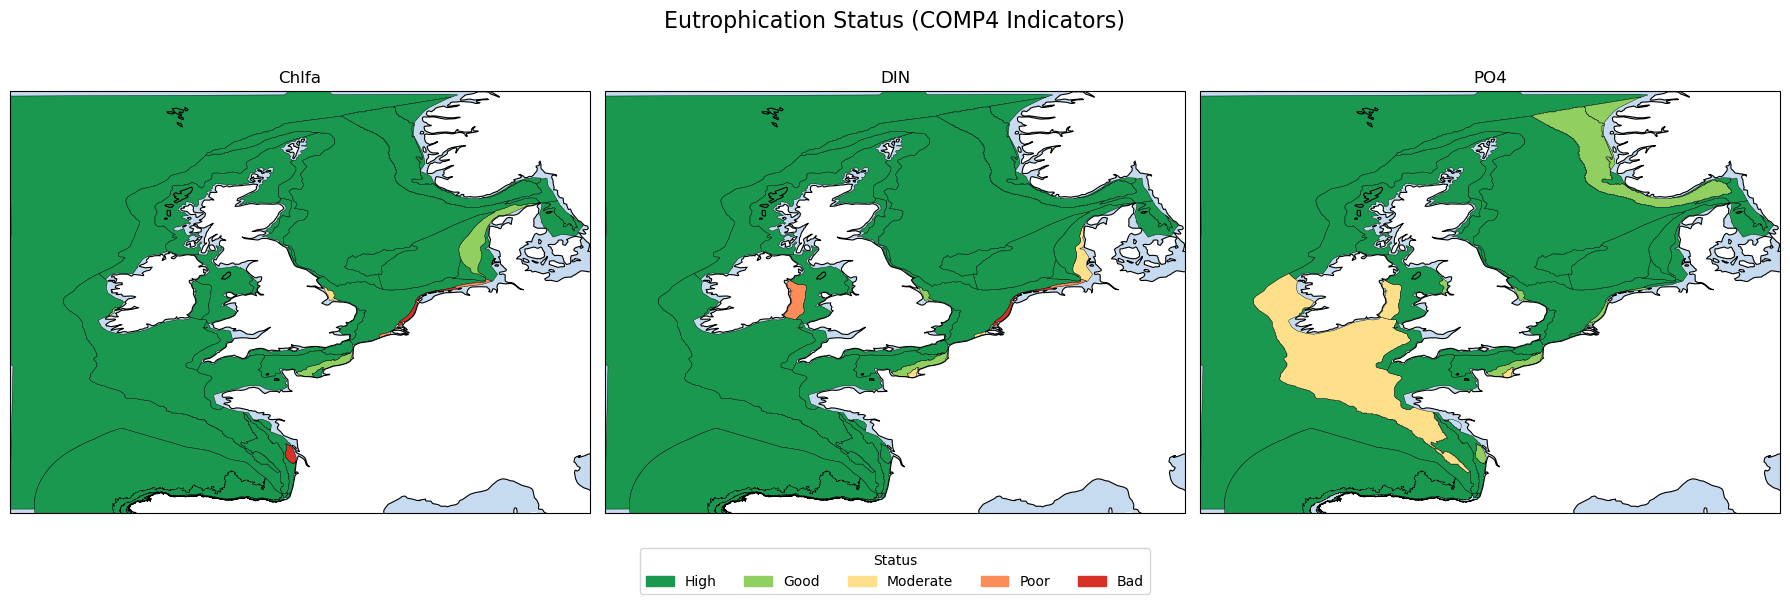

In [6]:

ds=xr.open_dataset(r'data/OSPAR_metrics_EQR_2015_2020.nc')


def plot_eqr_all(ds):

    variables = ["Chlfa", "DIN", "PO4"]

    fig, axes = plt.subplots(
        1, 3, figsize=(18, 6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # --- color conversion function ---
    def to_rgba(c):
        if (
            c is None
            or (isinstance(c, float) and np.isnan(c))
            or (isinstance(c, str) and c.lower() in ["nan", "none", "transparent", ""])
        ):
            return (0, 0, 0, 0)  # transparent
        return mpl.colors.to_rgba(c)

    # --- loop over variables ---
    for ax, VAR in zip(axes, variables):

        color_var = f"Color_{VAR}"

        colors_raw = ds[color_var].values
        area_ids_ds = ds["OBJECTID"].values

        val_map = {str(a): c for a, c in zip(area_ids_ds, colors_raw)}

        colors = np.array([
            to_rgba(val_map.get(str(a), "transparent"))
            for a in area_ids
        ])

        # --- map background ---
        ax.add_feature(cfeature.LAND, facecolor='white')
        ax.add_feature(cfeature.OCEAN, facecolor="#c6dbef")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

        ax.set_extent([-15, 13, 43, 63])

        # --- plot polygons ---
        pc = PatchCollection(
            patches,
            facecolor=colors,
            edgecolor="black",
            linewidth=0.3
        )

        ax.add_collection(pc)

        ax.set_title(VAR)

    # --- shared legend ---
    legend_colors = {
        'High': '#1a9850',
        'Good': '#91cf60',
        'Moderate': '#fee08b',
        'Poor': '#fc8d59',
        'Bad': '#d73027'
    }

    legend_handles = [
        mpatches.Patch(color=c, label=k)
        for k, c in legend_colors.items()
    ]

    fig.legend(
        handles=legend_handles,
        title="Status",
        loc='lower center',
        ncol=5
    )

    plt.suptitle("Eutrophication Status (COMP4 Indicators)", fontsize=16)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

    


# Plot Chl-a status
plot_eqr_all(ds)

# How was this application made and more information 

#### Further details on the application schematization are given in the file underneath. Links to the different model and data improvements can also be explored, including the deliverables. 

In [7]:

from IPython.display import IFrame
IFrame("imgs/DF111.pdf", width=1700, height=1000)
